In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

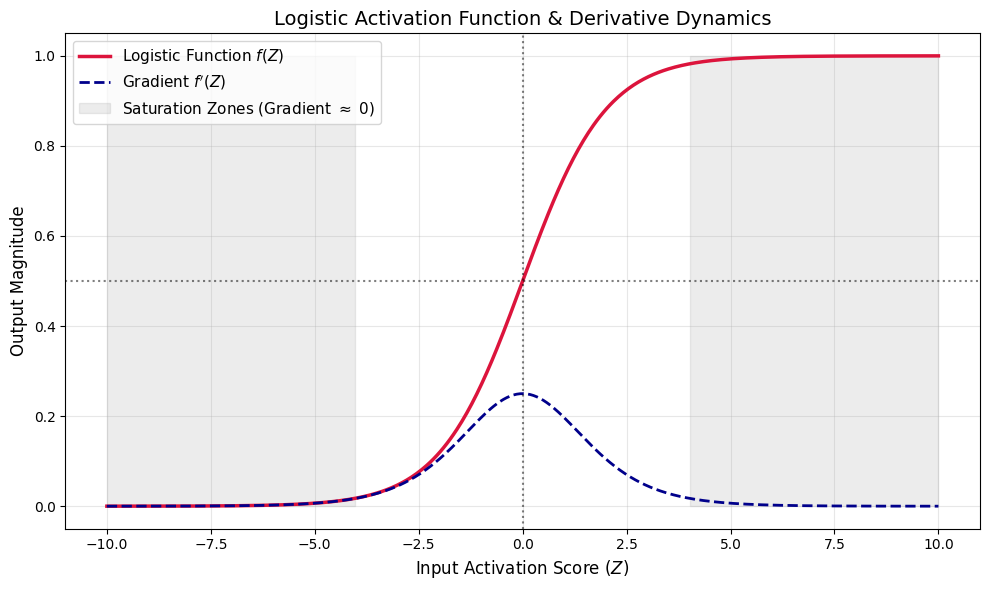

=== LOGISTIC RUNTIME GRADIENT ANALYSIS ===
At Z = -5 -> Activation: 0.0067 | Gradient: 0.0066
At Z =  0 -> Activation: 0.5000 | Gradient: 0.2500
At Z =  5 -> Activation: 0.9933 | Gradient: 0.0066


In [2]:
# Topic 145 | ANN - Logistic Activation Function
import numpy as np
import matplotlib.pyplot as plt

# 1. Inputs create karein (-10 se +10 tak)
z = np.linspace(-10, 10, 500)

# 2. Logistic Function aur uske Derivative ki manual calculations
logistic_output = 1 / (1 + np.exp(-z))
logistic_gradient = logistic_output * (1 - logistic_output)

# ------------------------------------------------------------------
# 3. PLOTTING THE COHESION
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plotting Logistic Function
plt.plot(z, logistic_output, color='crimson', linewidth=2.5, label='Logistic Function $f(Z)$')

# Plotting Derivative
plt.plot(z, logistic_gradient, color='darkblue', linewidth=2, linestyle='--', label="Gradient $f'(Z)$")

# Highlighting Saturation Regions
plt.fill_between(z, 0, 1, where=(z > 4) | (z < -4), color='gray', alpha=0.15, label='Saturation Zones (Gradient $\\approx$ 0)')

plt.title('Logistic Activation Function & Derivative Dynamics', fontsize=14)
plt.xlabel('Input Activation Score ($Z$)', fontsize=12)
plt.ylabel('Output Magnitude', fontsize=12)
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='black', linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sample metrics print karein
print("=== LOGISTIC RUNTIME GRADIENT ANALYSIS ===")
for sample_z in [-5, 0, 5]:
    val = 1 / (1 + np.exp(-sample_z))
    grad = val * (1 - val)
    print(f"At Z = {sample_z:2d} -> Activation: {val:.4f} | Gradient: {grad:.4f}")

In [3]:
# Topic 146 | ANN - Backpropagation Algorithm
import numpy as np

print("=== MANUAL BACKPROPAGATION TRACK ===")

# 1. Inputs and Ground Truth
X = np.array([1.5, 2.0])  # Input features
y_actual = 1.0            # Asli target (True Label)

# 2. Randomly Initialized Weights and Bias for a single neuron
W = np.array([0.4, -0.6])
b = 0.1
learning_rate = 0.1

print(f"Initial Weights: {W} | Initial Bias: {b}")

# ------------------------------------------------------------------
# STEP 1: FORWARD PASS (Prediction)
# ------------------------------------------------------------------
z = np.dot(X, W) + b
# Sigmoid Activation Function
y_pred = 1 / (1 + np.exp(-z))

# Mean Squared Error Loss for a single sample: (y_pred - y_actual)^2
loss = (y_pred - y_actual) ** 2

print("\n--- Forward Pass Output ---")
print(f"Linear Combo (z): {z:.4f}")
print(f"Prediction (y_pred): {y_pred:.4f}")
print(f"Current Loss: {loss:.4f}")

# ------------------------------------------------------------------
# STEP 2: BACKPROPAGATION (Calculus Chain Rule)
# ------------------------------------------------------------------
# 1. dLoss/dy_pred (Derivative of Loss w.r.t Prediction)
d_loss_d_pred = 2 * (y_pred - y_actual)

# 2. dy_pred/dz (Derivative of Sigmoid activation)
d_pred_d_z = y_pred * (1 - y_pred)

# 3. dz/dW (Derivative of linear combination w.r.t Weights is just the Input X)
d_z_d_w = X

# Chain Rule Integration: dLoss/dW = dLoss/dy_pred * dy_pred/dz * dz/dW
d_loss_d_z = d_loss_d_pred * d_pred_d_z  # Error signal delta
d_loss_d_w = d_loss_d_z * d_z_d_w
d_loss_d_b = d_loss_d_z * 1              # dz/db is always 1

print("\n--- Computed Gradients ---")
print(f"Gradient w.r.t Weights (dL/dW): {d_loss_d_w}")
print(f"Gradient w.r.t Bias (dL/dB): {d_loss_d_b:.4f}")

# ------------------------------------------------------------------
# STEP 3: GRADIENT DESCENT (Weights Optimization)
# ------------------------------------------------------------------
W_updated = W - (learning_rate * d_loss_d_w)
b_updated = b - (learning_rate * d_loss_d_b)

print("\n--- Optimized Parameters ---")
print(f"New Weights after Backprop: {W_updated}")
print(f"New Bias after Backprop: {b_updated:.4f}")

# Re-checking loss after one optimization step
z_new = np.dot(X, W_updated) + b_updated
y_pred_new = 1 / (1 + np.exp(-z_new))
new_loss = (y_pred_new - y_actual) ** 2
print(f"New Prediction: {y_pred_new:.4f} | New Loss: {new_loss:.4f} (Galti kam ho gayi!)")

=== MANUAL BACKPROPAGATION TRACK ===
Initial Weights: [ 0.4 -0.6] | Initial Bias: 0.1

--- Forward Pass Output ---
Linear Combo (z): -0.5000
Prediction (y_pred): 0.3775
Current Loss: 0.3875

--- Computed Gradients ---
Gradient w.r.t Weights (dL/dW): [-0.43884076 -0.58512101]
Gradient w.r.t Bias (dL/dB): -0.2926

--- Optimized Parameters ---
New Weights after Backprop: [ 0.44388408 -0.5414879 ]
New Bias after Backprop: 0.1293
New Prediction: 0.4285 | New Loss: 0.3266 (Galti kam ho gayi!)


2026-06-19 17:44:08.449007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781891048.697782      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781891048.769243      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781891049.430463      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781891049.430519      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781891049.430523      16 computation_placer.cc:177] computation placer alr

=== STARTING ANN TRAINING PROCESS ENGINE ===

Launching Training Process...
Epoch 1/20


2026-06-19 17:44:26.906869: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8300 - loss: 0.4240 - val_accuracy: 0.8900 - val_loss: 0.3152
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8737 - loss: 0.2722 - val_accuracy: 0.9000 - val_loss: 0.2802
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8913 - loss: 0.2474 - val_accuracy: 0.9000 - val_loss: 0.2548
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.2141 - val_accuracy: 0.9150 - val_loss: 0.2101
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9325 - loss: 0.1645 - val_accuracy: 0.9550 - val_loss: 0.1518
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9675 - loss: 0.0978 - val_accuracy: 0.9700 - val_loss: 0.0886
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9837 - loss: 0.0584 - val_accuracy: 0.9700 - val_loss: 0.0698
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9875 - loss: 0.0422 - val_accuracy: 0.9750 - val_loss: 0.0601
Ep

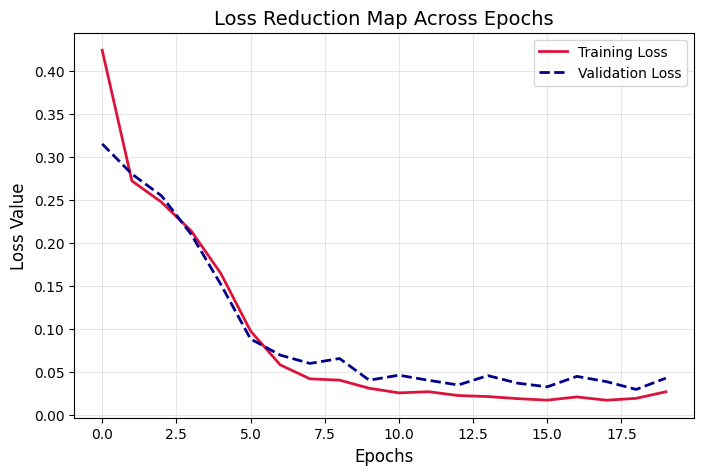

In [4]:
# Topic 147 | ANN - Neural Network Training Process
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

print("=== STARTING ANN TRAINING PROCESS ENGINE ===")

# 1. Dataset Generation (Non-linear Moon Dataset)
X_raw, y = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Preprocessing: Scale features for gradient stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Model Architecture Design
model = Sequential([
    Input(shape=(2,)),                                # 2 Input Features
    Dense(units=16, activation='relu', name='Hidden_1'), # Hidden Layer 1
    Dense(units=8, activation='relu', name='Hidden_2'),  # Hidden Layer 2
    Dense(units=1, activation='sigmoid', name='Output')  # Binary Output Layer
])

# ------------------------------------------------------------------
# STEP 3: COMPILATION (Setting up the Loss and Optimizer)
# ------------------------------------------------------------------
# Adam optimizer standard compilation choice hai jo learning rate ko dynamically adjust karta hai
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------------
# STEP 4: MODEL FITTING (The Actual Training Loop)
# ------------------------------------------------------------------
print("\nLaunching Training Process...")
history = model.fit(
    X_scaled, y,
    epochs=20,          # Poore dataset ko 20 dafa iterate kiya jayega
    batch_size=32,       # Har step mein 32 samples load honge
    validation_split=0.2, # 20% data testing/validation ke liye alag rahega
    verbose=1           # Progress bar print karne ke liye
)

# ------------------------------------------------------------------
# STEP 5: VISUALIZING TRAINING LOSS PROGRESSION
# ------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkblue', linewidth=2, linestyle='--')
plt.title('Loss Reduction Map Across Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
# Topic 148 | ANN - Training Parameters & Learning Rate
import os
# Internal backend system logs ko debug level par mute karne ke liye
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("=== CONFIGURING TRAINING PARAMETERS & OPTIMIZERS ===")

# 1. Custom Model Structure (3 Features -> 5 Hidden -> 1 Output)
model = Sequential([
    Input(shape=(3,)),
    Dense(units=5, activation='relu', name='Hidden_Layer'),
    Dense(units=1, activation='sigmoid', name='Output_Layer')
])

# Math Verification of Parameters:
# Hidden Layer: (3 inputs * 5 neurons) + 5 biases = 20 params
# Output Layer: (5 inputs * 1 neuron) + 1 bias    = 6 params
# Total expected parameters = 20 + 6 = 26

# 2. Custom Learning Rate Selector Setup
# Hum standard Adam optimizer choose kar rahe hain aur learning rate explicitly set kar rahe hain
custom_learning_rate = 0.02
optimizer_engine = tf.keras.optimizers.Adam(learning_rate=custom_learning_rate)

# Model compile karein
model.compile(
    optimizer=optimizer_engine,
    loss='binary_crossentropy'
)

# 3. Parameter Matrix Audit Print karein
print("\n--- Network Structure Mapping ---")
model.summary()

print(f"\nConfigured Learning Rate Strategy (Alpha): {custom_learning_rate}")

=== CONFIGURING TRAINING PARAMETERS & OPTIMIZERS ===

--- Network Structure Mapping ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)


Configured Learning Rate Strategy (Alpha): 0.02


In [6]:
# Topic 149 | ANN - Model Evaluation Metrics
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error

print("=== REAL-WORLD MODEL EVALUATION ENGINE ===")

# 1. CLASSIFICATION METRICS SIMULATION (e.g., Cancer Detection)
# Ground truth (Asli labels: 0 = Healthy, 1 = Cancer)
y_true_cls = np.array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])
# Model prediction probabilities from output layer (Sigmoid outputs)
y_pred_probs = np.array([0.15, 0.88, 0.05, 0.34, 0.42, 0.95, 0.12, 0.76, 0.61, 0.91])

# Apply classification threshold (Standard 0.5 rule)
y_pred_cls = (y_pred_probs >= 0.5).astype(int)

print("\n--- Classification Performance Report ---")
print(classification_report(y_true_cls, y_pred_cls, target_names=['Healthy', 'Cancer']))

print("Confusion Matrix Layout:")
print(confusion_matrix(y_true_cls, y_pred_cls))


# ------------------------------------------------------------------
# 2. REGRESSION METRICS SIMULATION (e.g., Gold Price Prediction)
# ------------------------------------------------------------------
y_true_reg = np.array([2050.5, 2065.0, 2042.1, 2080.0])
y_pred_reg = np.array([2048.0, 2069.2, 2035.0, 2078.5])

mse = mean_squared_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("\n--- Regression Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} Gold Units")

=== REAL-WORLD MODEL EVALUATION ENGINE ===

--- Classification Performance Report ---
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80         5
      Cancer       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

Confusion Matrix Layout:
[[4 1]
 [1 4]]

--- Regression Performance Metrics ---
Mean Squared Error (MSE): 19.1375
Root Mean Squared Error (RMSE): 4.3746 Gold Units


In [7]:
# Topic 150 | ANN - Model Validation & Cross Validation
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import KFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

print("=== STARTING CROSS-VALIDATION ENGINE ===")

# 1. Dummy Dataset setup (500 Samples, 10 Features)
X_raw, y = make_classification(n_samples=500, n_features=10, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. K-Fold configuration (Hum 3 Folds use kar rahe hain taake processing fast ho)
kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_no = 1
scores_per_fold = []

# ------------------------------------------------------------------
# 3. CROSS VALIDATION LOOP
# ------------------------------------------------------------------
for train_idx, val_idx in kf.split(X_scaled):
    
    # Data Split coordinates for current fold
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Fresh initialization of model architecture for each fold
    model = Sequential([
        Input(shape=(10,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    print(f"\nTraining Fold {fold_no}...")
    # Model fitting for current fold
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate performance on validation fold
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"-> Fold {fold_no} Complete. Validation Accuracy: {accuracy*100:.2f}%")
    
    scores_per_fold.append(accuracy)
    fold_no += 1

# ------------------------------------------------------------------
# 4. FINAL CROSS-VALIDATION REPORT
# ------------------------------------------------------------------
print("\n=== FINAL ROBUST EVALUATION REPORT ===")
print(f"Individual Fold Scores: {scores_per_fold}")
print(f"Mean Cross-Validation Accuracy: {np.mean(scores_per_fold)*100:.2f}%")
print(f"Standard Deviation (Stability Check): {np.std(scores_per_fold):.4f}")

=== STARTING CROSS-VALIDATION ENGINE ===

Training Fold 1...
-> Fold 1 Complete. Validation Accuracy: 82.04%

Training Fold 2...
-> Fold 2 Complete. Validation Accuracy: 68.26%

Training Fold 3...
-> Fold 3 Complete. Validation Accuracy: 71.69%

=== FINAL ROBUST EVALUATION REPORT ===
Individual Fold Scores: [0.8203592896461487, 0.682634711265564, 0.7168674468994141]
Mean Cross-Validation Accuracy: 74.00%
Standard Deviation (Stability Check): 0.0585


=== STARTING NEURAL NETWORK SIMULATION ENGINE ===

Simulating Neural Network Training over 40 Epochs...
Simulation Complete! Preparing Visual Dashboard...


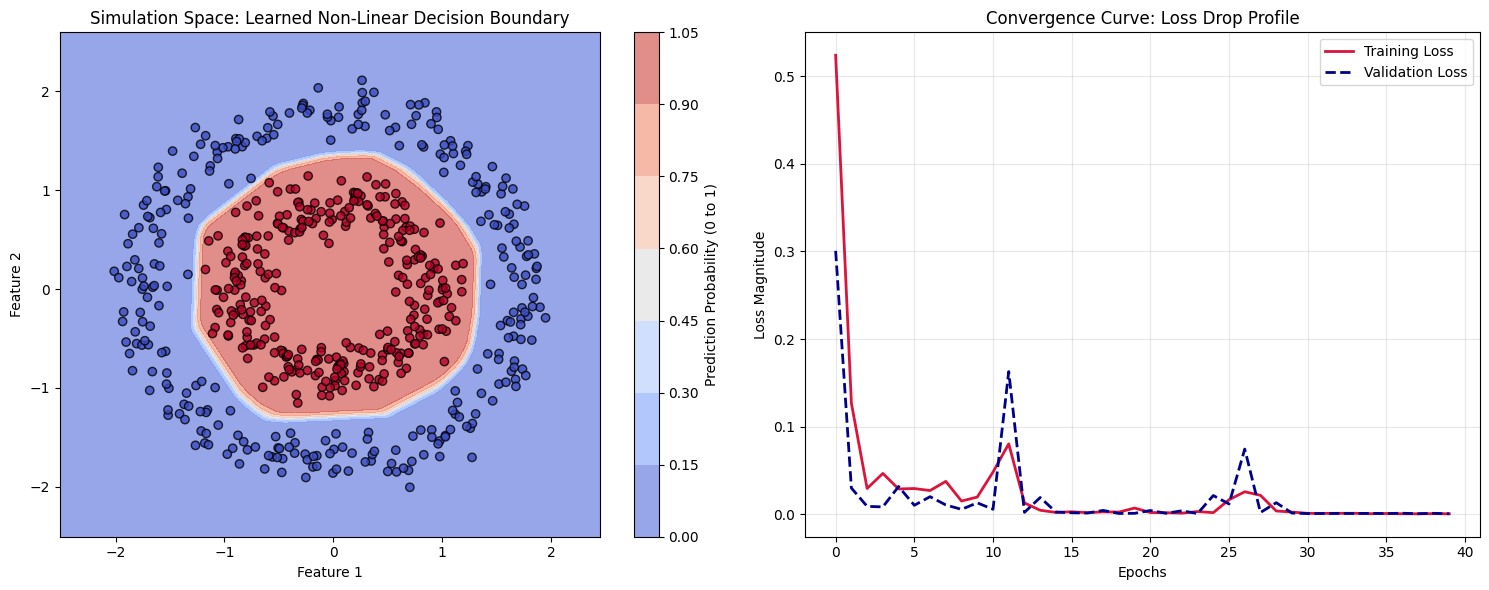

In [8]:
# Topic 151 | ANN - Neural Network Simulation
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

print("=== STARTING NEURAL NETWORK SIMULATION ENGINE ===")

# 1. Dataset Generation: Concentric Circles (Aik circle ke andar dusra circle)
# Yeh data linear algorithms (like logistic regression) se kabhi solve nahi ho sakta
X_raw, y = make_circles(n_samples=600, noise=0.08, factor=0.5, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Designing a Deep Network for Complex Geometry
model = Sequential([
    Input(shape=(2,)),                                # 2D Space Inputs (X, Y coordinates)
    Dense(units=32, activation='relu', name='Hidden_1'), # Higher neurons to capture curvature
    Dense(units=16, activation='relu', name='Hidden_2'),
    Dense(units=1, activation='sigmoid', name='Output')  # Probability output
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Running the Simulation Loop & Saving History
print("\nSimulating Neural Network Training over 40 Epochs...")
history = model.fit(
    X_scaled, y, 
    epochs=40, 
    batch_size=32, 
    validation_split=0.2,
    verbose=0  # Progress logs ko clean rakhne ke liye verbose 0 kiya hai
)

print("Simulation Complete! Preparing Visual Dashboard...")

# ------------------------------------------------------------------
# 4. DECISION BOUNDARY MESH GENERATION (The Simulation Visualizer)
# ------------------------------------------------------------------
# Grid points create karte hain pure data space ko cover karne ke liye
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Matrix space par predictions run karte hain
grid_predictions = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
grid_predictions = grid_predictions.reshape(xx.shape)

# Plotting the Simulation Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Dashboard Pane 1: Learned Decision Boundary Space
contour = ax1.contourf(xx, yy, grid_predictions, cmap='coolwarm', alpha=0.6)
scatter = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
ax1.set_title('Simulation Space: Learned Non-Linear Decision Boundary', fontsize=12)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
fig.colorbar(contour, ax=ax1, label='Prediction Probability (0 to 1)')

# Dashboard Pane 2: Convergence Metrics (Loss Convergence)
ax2.plot(history.history['loss'], label='Training Loss', color='crimson', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='darkblue', linewidth=2, linestyle='--')
ax2.set_title('Convergence Curve: Loss Drop Profile', fontsize=12)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Magnitude')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# Topic 152 | ANN - Implementation with TensorFlow/Keras
import os
# TensorFlow ke internal system warnings ko clean rakhne ke liye log level set karein
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== STARTING TENSORFLOW/KERAS PRODUCTION ENGINE ===")

# 1. DATA PREPARATION: 1000 Samples with 20 Raw Features
X_raw, y_raw = make_classification(
    n_samples=1000, n_features=20, n_informative=15, n_classes=2, random_state=42
)

# Holdout Method Apply karein (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Deep Learning mein Scaling ke bagair gradients unstable ho jate hain
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training Matrix Shape: {X_train.shape}")
print(f"Testing Matrix Shape: {X_test.shape}\n")

# ------------------------------------------------------------------
# STEP 2: DESIGNING THE NETWORK ARCHITECTURE
# ------------------------------------------------------------------
# Sequential approach use karte hue stackable model ready karein
model = Sequential([
    Input(shape=(20,)),                                 # Input Layer (20 Features)
    Dense(units=32, activation='relu', name='Hidden_1'),   # Dense Hidden Layer 1
    Dense(units=16, activation='relu', name='Hidden_2'),   # Dense Hidden Layer 2
    Dense(units=1, activation='sigmoid', name='Output')   # Output Layer for Binary Class
])

# ------------------------------------------------------------------
# STEP 3: THE COMPILATION MECHANISM
# ------------------------------------------------------------------
# Model ko train hone se pehle configure karna zaroori hai
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), # Adaptive learning rate engine
    loss='binary_crossentropy',                              # Standard binary classification loss
    metrics=['accuracy']                                     # Tracking metrics
)

print("--- Neural Network Structural Summary ---")
model.summary()

# ------------------------------------------------------------------
# STEP 4: MODEL FITTING (The Execution Loop)
# ------------------------------------------------------------------
print("\nLaunching Training Progress Block...")
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,  # 15% training data training ke sath validation ke liye use hoga
    verbose=1               # Progress bar real-time dekhne ke liye
)

# ------------------------------------------------------------------
# STEP 5: DOWNSTREAM EVALUATION & INFERENCE
# ------------------------------------------------------------------
print("\n=== RUNNING PRODUCTION METRIC AUDIT ===")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

# Naye sample par prediction ka tarika (Inference)
dummy_unseen_sample = np.random.randn(1, 20)  # Single array with 20 features
scaled_sample = scaler.transform(dummy_unseen_sample)

prediction_probability = model.predict(scaled_sample, verbose=0)
print(f"\nLive Inference Check:")
print(f"-> Unseen Sample Positive Class Probability: {prediction_probability[0][0]*100:.2f}%")

=== STARTING TENSORFLOW/KERAS PRODUCTION ENGINE ===
Training Matrix Shape: (800, 20)
Testing Matrix Shape: (200, 20)

--- Neural Network Structural Summary ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_1 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)


Launching Training Progress Block...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7000 - loss: 0.5878 - val_accuracy: 0.7833 - val_loss: 0.4754
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8632 - loss: 0.3719 - val_accuracy: 0.8583 - val_loss: 0.3440
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8897 - loss: 0.2657 - val_accuracy: 0.8667 - val_loss: 0.3195
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9250 - loss: 0.2013 - val_accuracy: 0.8833 - val_loss: 0.2823
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9485 - loss: 0.1582 - val_accuracy: 0.8917 - val_loss: 0.2521
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9603 - loss: 0.1276 - val_accuracy: 0.8833 - val_loss: 0.2719
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9647 - loss: 0.1089 - val_accuracy: 0.8917 - val_loss: 0.2523
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9750 - loss: 0.

=== SIMULATING CNN FILTER CONVOLUTION ===


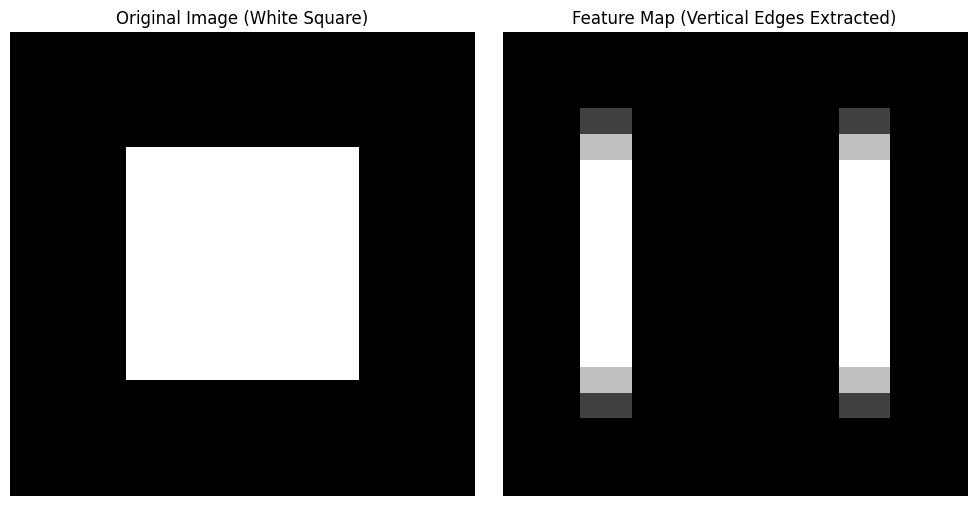

Convolution Simulation Successful! Notice how the edges glow white in the feature map.


In [10]:
# Topic 153 | Introduction to Convolutional Neural Networks (CNN)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

print("=== SIMULATING CNN FILTER CONVOLUTION ===")

# 1. Fake Image generate karte hain (Ek square shape background par)
# 0 = Black, 255 = White
image = np.zeros((20, 20))
image[5:15, 5:15] = 255  # Beech mein ek white square block

# 2. Sobel Filter define karte hain (Vertical Edge Detection ke liye)
# Yeh filter left aur right sides ke farq ko naapta hai
vertical_filter = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# 3. Convolution Operation run karte hain
# Image par filter ko slide kar ke output feature map nikalna
feature_map = convolve2d(image, vertical_filter, mode='valid')

# 4. Results plot karte hain
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image (White Square)')
ax1.axis('off')

ax2.imshow(np.abs(feature_map), cmap='gray')
ax2.set_title('Feature Map (Vertical Edges Extracted)')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("Convolution Simulation Successful! Notice how the edges glow white in the feature map.")

In [11]:
# Topic 154 | CNN - Training a Convolutional Neural Network
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("=== COGNITIVE CNN TRAINING ENGINE LAUNCHED ===")

# 1. Load and Preprocess MNIST Dataset (0 se 9 tak ke hathon se likhe digits)
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# CNN input ke liye 4D shape zaroori hai: (Samples, Height, Width, Channels)
# Grayscale image hai isliye channel size 1 hoga. Normalizing pixels to 0-1 range.
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0

print(f"Train Images Shape: {train_images.shape}")
print(f"Test Images Shape: {test_images.shape}\n")

# 2. Designing the CNN Architecture
model = models.Sequential([
    # First Conv Block: 32 Filters of size 3x3
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='Conv_Layer_1'),
    layers.MaxPooling2D((2, 2), name='Max_Pooling_1'),
    
    # Second Conv Block: 64 Filters of size 3x3
    layers.Conv2D(64, (3, 3), activation='relu', name='Conv_Layer_2'),
    layers.MaxPooling2D((2, 2), name='Max_Pooling_2'),
    
    # Flattening to transition into dense classifier
    layers.Flatten(name='Flatten_Layer'),
    layers.Dense(64, activation='relu', name='Dense_Hidden'),
    layers.Dense(10, activation='softmax', name='Output_Classifier') # 10 classes (0 to 9)
])

# 3. Model Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Multi-class integer classification loss
    metrics=['accuracy']
)

model.summary()

# 4. Training the CNN Model
print("\nStarting CNN Training over 5 Epochs...")
history = model.fit(
    train_images, train_labels, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.1,
    verbose=1
)

# 5. Model Evaluation on Unseen Test Images
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

=== COGNITIVE CNN TRAINING ENGINE LAUNCHED ===
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train Images Shape: (60000, 28, 28, 1)
Test Images Shape: (10000, 28, 28, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_Layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_1 (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_2 (Conv2D)           │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_2 (MaxPooling2D)    │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Layer (Flatten)         │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


Starting CNN Training over 5 Epochs...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.9430 - loss: 0.1871 - val_accuracy: 0.9858 - val_loss: 0.0509
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9832 - loss: 0.0539 - val_accuracy: 0.9808 - val_loss: 0.0648
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9893 - val_loss: 0.0432
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9912 - loss: 0.0302 - val_accuracy: 0.9907 - val_loss: 0.0342
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9925 - loss: 0.0231 - val_accuracy: 0.9903 - val_loss: 0.0316

Final Test Accuracy: 98.81%


In [12]:
# Topic 155 | CNN - Building a CNN Model with TensorFlow/Keras
import os
# Internal backend logs aur warnings ko clean rakhne ke liye log level set karein
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

print("=== ARCHITECTING CUSTOM CNN MODEL WITH KERAS ===")

# 1. Building the Stackable Sequential CNN
model = Sequential([
    # Standard Gatekeeper: Input tensor shape for a 64x64 Color Image (3 Channels: RGB)
    Input(shape=(64, 64, 3)),
    
    # First Conv Block: Extracts basic textures and lines
    # 32 filters, 3x3 size, padding='same' wraps the borders perfectly
    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', name='Conv_Block_1'),
    MaxPooling2D(pool_size=(2, 2), name='Max_Pool_1'), # Reduces size to 32x32
    
    # Second Conv Block: Extracts detailed shapes (eyes, corners)
    # Increasing filters to 64 as spatial matrix size decreases
    Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', name='Conv_Block_2'),
    MaxPooling2D(pool_size=(2, 2), name='Max_Pool_2'), # Reduces size to 16x16
    
    # Third Conv Block: Deep complex structures
    Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu', name='Conv_Block_3'),
    MaxPooling2D(pool_size=(2, 2), name='Max_Pool_3'), # Reduces size to 8x8
    
    # ------------------------------------------------------------------
    # TRANSITION & CLASSIFICATION PHASES
    # ------------------------------------------------------------------
    # Flattening: Converts (8, 8, 128) 3D matrix into a 1D vector of 8 * 8 * 128 = 8192 cells
    Flatten(name='Flatten_Bridge'),
    
    # Fully Connected Hidden Layer for high-level correlation learning
    Dense(units=128, activation='relu', name='Dense_Fully_Connected'),
    
    # Final Output Layer: 1 Neuron with Sigmoid for Binary Classification (e.g., Cat vs Dog)
    Dense(units=1, activation='sigmoid', name='Output_Classifier')
])

# 2. Compiling the Engine
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Printing the Structural Audit
print("\n--- CNN Architecture Tensor Topology Summary ---")
model.summary()

=== ARCHITECTING CUSTOM CNN MODEL WITH KERAS ===

--- CNN Architecture Tensor Topology Summary ---


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_Block_1 (Conv2D)           │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Block_2 (Conv2D)           │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Block_3 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Bridge (Flatten)        │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Fully_Connected (Dense)   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Topic 156 | Introduction to Recurrent Neural Networks (RNN)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

print("=== INITIALIZING RECURRENT NEURAL NETWORK ===")

# Model Configuration
# Farz karein hamare paas 10 words ka text sequence hai, aur har word ka vector size 5 hai
time_steps = 10
features_per_step = 5

model = Sequential([
    # Input Shape: (Sequence_Length, Feature_Dimension)
    Input(shape=(time_steps, features_per_step)),
    
    # SimpleRNN Layer: 32 hidden units (Internal Memory state size)
    SimpleRNN(units=32, activation='tanh', return_sequences=False, name='RNN_Memory_Cell'),
    
    # Final Output Layer (e.g., Binary classification)
    Dense(units=1, activation='sigmoid', name='Dense_Classifier')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- RNN Topology Structural Summary ---")
model.summary()

=== INITIALIZING RECURRENT NEURAL NETWORK ===

--- RNN Topology Structural Summary ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ RNN_Memory_Cell (SimpleRNN)     │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Classifier (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)